<a href="https://colab.research.google.com/github/Norah-444/Machine-Learning-Project/blob/main/IT461-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST Clothing Classification
### IT461 — Machine Learning Project
**Team Members:**

| Name | Student ID |
|------|-----------|
| Rana Khalil Alngashy | 444204737 |
| Ghalia Saad Alkhaldi | 444200534 |
| Layan Alhowaimel | 444200969 |
| Norah Riyadh Aljayan | 444200832 |
---

## Project Description

This notebook implements and compares three machine learning approaches for
multi-class image classification on the **Fashion-MNIST** dataset — a benchmark
dataset of 70,000 grayscale images (28×28 pixels) spanning 10 clothing categories:
T-shirt/Top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, and Ankle Boot.

The goal is to train models that can correctly identify the clothing category of
an unseen image, and to evaluate how different learning paradigms compare on this task.

Three methods are implemented:
- **Convolutional Neural Network (CNN)** — a deep learning model that learns spatial
  feature hierarchies directly from raw pixels
- **K-Nearest Neighbors (KNN)** — a distance-based classifier operating on
  PCA-reduced pixel features
- **Support Vector Machine (SVM)** — trained with both RBF and Polynomial kernels
  on PCA-reduced features

Each model is tuned using hyperparameter search, evaluated using classification
accuracy and weighted F1-score, and analyzed through confusion matrices and
per-class classification reports. The notebook concludes with a saved-model demo
that loads all three best models and runs inference on five test examples.

**Dataset:** Fashion-MNIST (Zalando Research) — 60,000 training samples, 10,000 test samples  
**Framework:** PyTorch (CNN), scikit-learn (KNN, SVM)  
**Hardware:** CPU (CUDA GPU used automatically if available)

## 1. Setup & Imports

All required libraries are imported here at the start of the notebook.
PyTorch and torchvision handle the CNN pipeline. scikit-learn provides
the classical models, PCA, and GridSearchCV. Matplotlib and Seaborn are
used for all visualizations. The device is set to GPU if available,
otherwise CPU.

In [ ]:
# ==========================================
# SETUP & IMPORTS
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Clean, minimal dark theme for presentation visuals
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "text.color": "white", "axes.labelcolor": "white", "xtick.color": "white", "ytick.color": "white"})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Dataset & Visualization

The Fashion-MNIST dataset is loaded directly via torchvision. It contains
70,000 grayscale images (28×28 pixels) across 10 clothing categories.
The training set (60,000 samples) is used to train the CNN. A stratified
subset of 10,000 training and 2,000 test samples is used for KNN and SVM
due to their higher computational cost. The cell below displays a sample
grid of images to verify the data loaded correctly.

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.2MB/s]


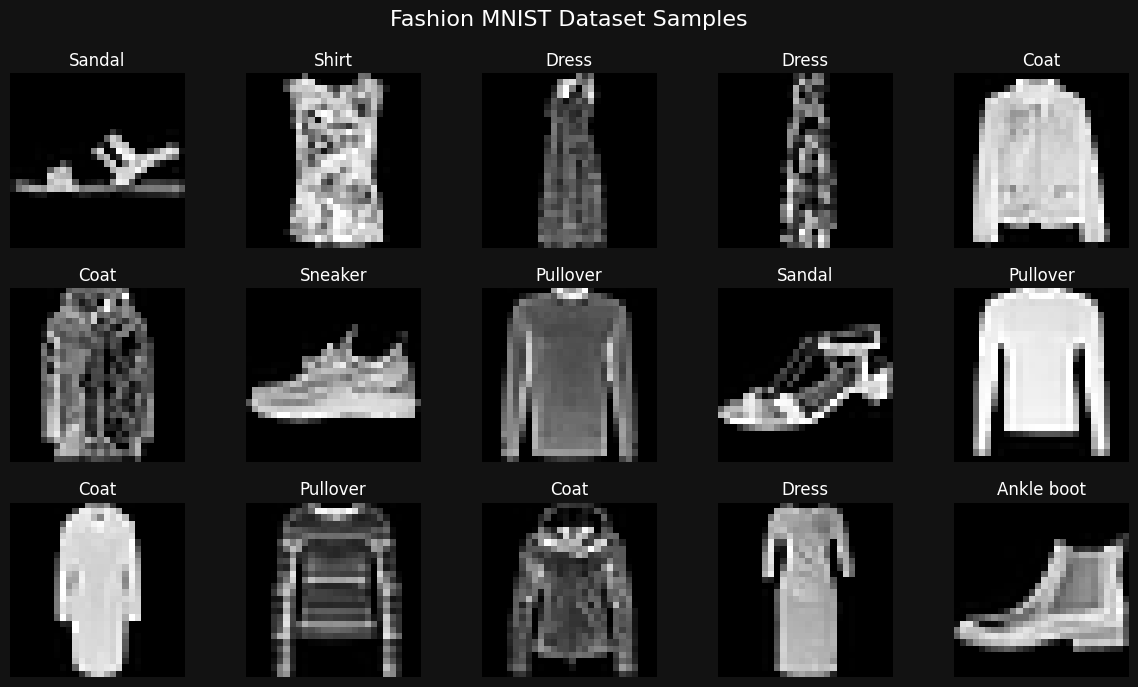


Feature Extraction Note for Slide 2:
In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.


In [ ]:
# ==========================================
#  DATASET & VISUALIZATION
# ==========================================
# Load Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
val_ds = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

classes = train_ds.classes

# Generate a grid of examples for your presentation slide
def show_dataset_examples():
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(3, 5, figsize=(12, 7))
    fig.suptitle('Fashion MNIST Dataset Samples', fontsize=16, color='white')
    for i, ax in enumerate(axes.flat):
        img = images[i].numpy().squeeze()
        ax.imshow(img, cmap='gray')
        ax.set_title(classes[labels[i]], color='white')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_dataset_examples()

print("\nFeature Extraction Note for Slide 2:")
print("In this approach, we pass raw normalized pixel arrays (28x28) directly into a Convolutional Neural Network (CNN). The initial convolutional layers automatically act as our feature extractors, identifying edges, textures, and patterns without manual feature engineering.")

## 3. Model Definitions & Hyperparameter Tuning

### 3.1 CNN — Architecture & Training Function

The CNN consists of two convolutional blocks followed by a fully-connected
classifier head:
- **Conv Block 1:** Conv2d(1→16) → ReLU → MaxPool2d(2) — extracts low-level features (edges, gradients)
- **Conv Block 2:** Conv2d(16→32) → ReLU → MaxPool2d(2) — extracts higher-level patterns
- **Classifier:** Linear(1568→128) → ReLU → Dropout(p) → Linear(128→10)

The `FashionCNN` class accepts a configurable `dropout_rate` parameter to
support hyperparameter search. The `train_and_evaluate_cnn` function trains
one configuration and returns the model and its accuracy history.

In [ ]:
# ==========================================
#  METHODS & HYPERPARAMETER TUNING
# ==========================================
import itertools
import torch
import torch.nn as nn
import torch.optim as optim

class FashionCNN(nn.Module):
    """CNN with configurable dropout for hyperparameter search."""
    def __init__(self, dropout_rate=0.25):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x


def train_and_evaluate_cnn(lr, dropout_rate, epochs=8):
    """Train a single CNN configuration and return validation accuracy history."""
    model = FashionCNN(dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = correct / total
        history['train_loss'].append(epoch_loss)
        history['val_acc'].append(epoch_acc)
        print(f"  Epoch {epoch+1}/{epochs} — Loss: {epoch_loss:.4f}  Val Acc: {epoch_acc:.4f}")

    return model, history

### 3.2 CNN — Grid Search

A manual grid search is run over two hyperparameters: **learning rate**
and **dropout rate**, producing 9 configurations trained for 8 epochs each.
The configuration with the highest final validation accuracy is saved as
`best_cnn_model`.

| Hyperparameter | Values |
|----------------|--------|
| Learning Rate  | 0.01, 0.001, 0.0001 |
| Dropout Rate   | 0.0, 0.25, 0.5 |

In [ ]:
# ── Grid Search ────────────────────────────────────────────────────────────
learning_rates = [0.01, 0.001, 0.0001]
dropout_rates  = [0.0, 0.25, 0.5]
epochs         = 8          # more epochs for fair comparison
grid           = list(itertools.product(learning_rates, dropout_rates))

cnn_results    = []
best_cnn_acc   = 0
best_cnn_model = None
best_cnn_cfg   = None

print(f"CNN Grid Search: {len(grid)} configurations × {epochs} epochs\n")
print(f"{'Config':<35} {'Final Val Acc':>14}")
print("-" * 52)

for lr, dropout in grid:
    cfg_label = f"lr={lr}, dropout={dropout}"
    print(f"\n▶ Training {cfg_label} ...")
    model, history = train_and_evaluate_cnn(lr, dropout, epochs=epochs)
    final_acc = history['val_acc'][-1]
    cnn_results.append({
        'LR': lr, 'Dropout': dropout,
        'Final_Accuracy': final_acc,
        'History': history,
        'Label': cfg_label
    })
    print(f"  {cfg_label:<33} {final_acc*100:>13.2f}%")

    if final_acc > best_cnn_acc:
        best_cnn_acc   = final_acc
        best_cnn_model = model
        best_cnn_cfg   = cfg_label

print(f"\n{'='*52}")
print(f"Best CNN Config : {best_cnn_cfg}")
print(f"Best Val Acc    : {best_cnn_acc*100:.2f}%")


CNN Grid Search: 9 configurations × 8 epochs

Config                               Final Val Acc
----------------------------------------------------

▶ Training lr=0.01, dropout=0.0 ...
  Epoch 1/8 — Loss: 0.4472  Val Acc: 0.8646
  Epoch 2/8 — Loss: 0.3123  Val Acc: 0.8750
  Epoch 3/8 — Loss: 0.2877  Val Acc: 0.8801
  Epoch 4/8 — Loss: 0.2734  Val Acc: 0.8902
  Epoch 5/8 — Loss: 0.2624  Val Acc: 0.8887
  Epoch 6/8 — Loss: 0.2542  Val Acc: 0.8916
  Epoch 7/8 — Loss: 0.2439  Val Acc: 0.8920
  Epoch 8/8 — Loss: 0.2451  Val Acc: 0.8953
  lr=0.01, dropout=0.0                      89.53%

▶ Training lr=0.01, dropout=0.25 ...
  Epoch 1/8 — Loss: 0.4962  Val Acc: 0.8638
  Epoch 2/8 — Loss: 0.3617  Val Acc: 0.8684
  Epoch 3/8 — Loss: 0.3318  Val Acc: 0.8851
  Epoch 4/8 — Loss: 0.3216  Val Acc: 0.8800
  Epoch 5/8 — Loss: 0.3136  Val Acc: 0.8859
  Epoch 6/8 — Loss: 0.3079  Val Acc: 0.8831
  Epoch 7/8 — Loss: 0.3022  Val Acc: 0.8696
  Epoch 8/8 — Loss: 0.2995  Val Acc: 0.8821
  lr=0.01, dropout=0

### 3.3 CNN — Tuning Results & Learning Curves

The plots below show validation accuracy across 8 epochs for all 9
configurations, grouped by dropout rate. The summary table ranks all
configurations by final accuracy.

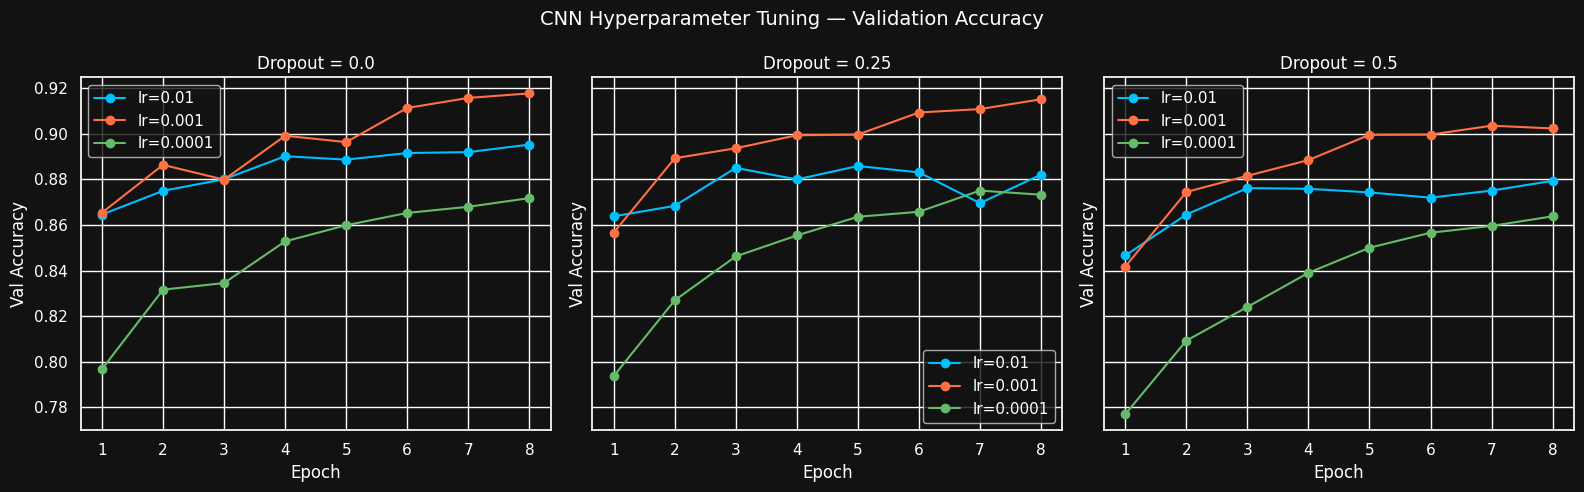


CNN Grid Search Results (sorted by accuracy):


,Learning Rate,Dropout Rate,Final Val Acc (%)
3,0.0010,0.00,91.78
4,0.0010,0.25,91.52
5,0.0010,0.50,90.24
0,0.0100,0.00,89.53
1,0.0100,0.25,88.21
2,0.0100,0.50,87.94
7,0.0001,0.25,87.33
6,0.0001,0.00,87.18
8,0.0001,0.50,86.38


In [ ]:
# ── Plot: All CNN curves grouped by dropout ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('CNN Hyperparameter Tuning — Validation Accuracy', fontsize=14, color='white')

for ax, dr in zip(axes, dropout_rates):
    configs_for_dr = [r for r in cnn_results if r['Dropout'] == dr]
    colors = ['#00BFFF', '#FF7043', '#66BB6A']
    for color, res in zip(colors, configs_for_dr):
        ax.plot(range(1, epochs+1), res['History']['val_acc'],
                marker='o', color=color, label=f"lr={res['LR']}")
    ax.set_title(f'Dropout = {dr}', color='white')
    ax.set_xlabel('Epoch', color='white')
    ax.set_ylabel('Val Accuracy', color='white')
    ax.legend()

plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
import pandas as pd
df_cnn = pd.DataFrame([{
    'Learning Rate': r['LR'],
    'Dropout Rate':  r['Dropout'],
    'Final Val Acc (%)': round(r['Final_Accuracy']*100, 2)
} for r in cnn_results]).sort_values('Final Val Acc (%)', ascending=False)

print("\nCNN Grid Search Results (sorted by accuracy):")
display(df_cnn)



### 3.4 KNN — Baseline & GridSearchCV Tuning

The KNN classifier uses a **PCA(100) + KNeighborsClassifier** pipeline.
PCA reduces the 784-dimensional pixel vectors to 100 components with
whitening, making distance metrics more meaningful. A baseline model
(k=5, Euclidean) is evaluated first, then GridSearchCV with 5-fold
cross-validation searches over k ∈ {3, 5, 7, 9} and metric ∈
{Euclidean, Manhattan} — 8 combinations total.

In [ ]:
# ==========================================
#  KNN METHOD & HYPERPARAMETER TUNING
# ==========================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# Flatten and normalize the data for sklearn models
X_train_flat = train_ds.data.numpy().reshape(-1, 784) / 255.0
X_test_flat  = val_ds.data.numpy().reshape(-1, 784)   / 255.0
y_train_flat = train_ds.targets.numpy()
y_test_flat  = val_ds.targets.numpy()

# Use a stratified subset (KNN is slow on 60k samples)
from sklearn.model_selection import train_test_split
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_flat, y_train_flat,
    train_size=10000, stratify=y_train_flat, random_state=42
)
X_test_sub, _, y_test_sub, _ = train_test_split(
    X_test_flat, y_test_flat,
    train_size=2000, stratify=y_test_flat, random_state=42
)

# Baseline KNN (no tuning)
knn_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    KNeighborsClassifier(n_neighbors=5)
)
knn_baseline.fit(X_train_sub, y_train_sub)
knn_base_pred = knn_baseline.predict(X_test_sub)
knn_base_acc  = accuracy_score(y_test_sub, knn_base_pred)
knn_base_f1   = f1_score(y_test_sub, knn_base_pred, average='weighted')
print(f"Baseline KNN — Accuracy: {knn_base_acc*100:.2f}%  F1: {knn_base_f1*100:.2f}%")

# GridSearchCV — Best KNN with PCA Pipeline
param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [3, 5, 7, 9],
    'kneighborsclassifier__metric':      ['euclidean', 'manhattan']
}

model_knn = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    KNeighborsClassifier()
)

grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, verbose=2)
grid_knn.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (KNN): {grid_knn.best_params_}")

print("\nAll CV results:")
for mean, std, param in zip(grid_knn.cv_results_['mean_test_score'],
                             grid_knn.cv_results_['std_test_score'],
                             grid_knn.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

# Evaluate best KNN
best_knn_model = grid_knn.best_estimator_
y_pred_knn     = best_knn_model.predict(X_test_sub)
best_knn_acc   = accuracy_score(y_test_sub, y_pred_knn)
best_knn_f1    = f1_score(y_test_sub, y_pred_knn, average='weighted')
print(f"\nBest KNN — Accuracy: {best_knn_acc*100:.2f}%  F1: {best_knn_f1*100:.2f}%")

Baseline KNN — Accuracy: 80.85%  F1: 81.13%
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   0.8s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=3; total time=   1.8s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   1.1s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   3.7s
[CV] END kneighborsclassifier__metric=euclidean, kneighborsclassifier__n_neighbors=5; total time=   1.5s
[CV] END kneighborsclassifier__metric=euclidean, kneighb

### 3.5 SVM — Baseline & GridSearchCV Tuning

Two SVM kernels are explored within the same **PCA(100) + SVC** pipeline.
Baselines are evaluated first, then GridSearchCV with 5-fold
cross-validation tunes each kernel independently.

- **RBF kernel:** searches C ∈ {1, 5, 10} × γ ∈ {0.0005, 0.001, 0.005} → 9 combinations
- **Polynomial kernel:** searches C ∈ {0.1, 1, 5, 10} × degree ∈ {2, 3, 4} × γ ∈ {scale, auto} → 24 combinations

In [ ]:
# ==========================================
#  SVM METHODS & HYPERPARAMETER TUNING
# ==========================================
from sklearn.svm import SVC

# ── Baseline SVM Models ──────────────────────────────────
rbf_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='rbf', gamma=0.005, C=5)
)
rbf_baseline.fit(X_train_sub, y_train_sub)
rbf_base_pred = rbf_baseline.predict(X_test_sub)
rbf_base_acc  = accuracy_score(y_test_sub, rbf_base_pred)
rbf_base_f1   = f1_score(y_test_sub, rbf_base_pred, average='weighted')
print(f"Baseline SVM RBF  — Accuracy: {rbf_base_acc*100:.2f}%  F1: {rbf_base_f1*100:.2f}%")

poly_baseline = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='poly', degree=3, C=1)
)
poly_baseline.fit(X_train_sub, y_train_sub)
poly_base_pred = poly_baseline.predict(X_test_sub)
poly_base_acc  = accuracy_score(y_test_sub, poly_base_pred)
poly_base_f1   = f1_score(y_test_sub, poly_base_pred, average='weighted')
print(f"Baseline SVM Poly — Accuracy: {poly_base_acc*100:.2f}%  F1: {poly_base_f1*100:.2f}%")

# ── GridSearchCV — Best RBF SVM ───────────────────────────
param_grid_rbf = {
    'svc__C':     [1, 5, 10],
    'svc__gamma': [0.0005, 0.001, 0.005]
}

model_rbf = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='rbf', class_weight='balanced')
)

grid_rbf = GridSearchCV(model_rbf, param_grid_rbf, cv=5, verbose=2)
grid_rbf.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (RBF): {grid_rbf.best_params_}")
for mean, std, param in zip(grid_rbf.cv_results_['mean_test_score'],
                             grid_rbf.cv_results_['std_test_score'],
                             grid_rbf.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

best_rbf_model = grid_rbf.best_estimator_
y_pred_rbf     = best_rbf_model.predict(X_test_sub)
best_rbf_acc   = accuracy_score(y_test_sub, y_pred_rbf)
best_rbf_f1    = f1_score(y_test_sub, y_pred_rbf, average='weighted')
print(f"\nBest SVM RBF — Accuracy: {best_rbf_acc*100:.2f}%  F1: {best_rbf_f1*100:.2f}%")

# ── GridSearchCV — Best Polynomial SVM ───────────────────
param_grid_poly = {
    'svc__C':      [0.1, 1, 5, 10],
    'svc__degree': [2, 3, 4],
    'svc__gamma':  ['scale', 'auto']
}

model_poly = make_pipeline(
    PCA(n_components=100, whiten=True, random_state=42),
    SVC(kernel='poly', class_weight='balanced')
)

grid_poly = GridSearchCV(model_poly, param_grid_poly, cv=5, verbose=2)
grid_poly.fit(X_train_sub, y_train_sub)

print(f"\nBest parameters (Polynomial): {grid_poly.best_params_}")
for mean, std, param in zip(grid_poly.cv_results_['mean_test_score'],
                             grid_poly.cv_results_['std_test_score'],
                             grid_poly.cv_results_['params']):
    print(f"  {round(mean,3)} ± {round(std,3)}  for  {param}")

best_poly_model = grid_poly.best_estimator_
y_pred_poly     = best_poly_model.predict(X_test_sub)
best_poly_acc   = accuracy_score(y_test_sub, y_pred_poly)
best_poly_f1    = f1_score(y_test_sub, y_pred_poly, average='weighted')
print(f"\nBest SVM Poly — Accuracy: {best_poly_acc*100:.2f}%  F1: {best_poly_f1*100:.2f}%")

Baseline SVM RBF  — Accuracy: 86.80%  F1: 86.80%
Baseline SVM Poly — Accuracy: 79.95%  F1: 81.45%
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.3s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   6.6s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.4s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.7s
[CV] END ........................svc__C=1, svc__gamma=0.0005; total time=   7.9s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.1s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   7.1s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   6.4s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.5s
[CV] END .........................svc__C=1, svc__gamma=0.001; total time=   5.6s
[CV] END .......................

### 3.6 Reusable Helper Functions

`evaluate_sklearn_model` is a shared utility used to evaluate any trained
sklearn pipeline. It prints accuracy, weighted F1-score, a full
classification report, and plots a confusion matrix. This avoids
duplicating evaluation code across KNN and SVM sections.

In [ ]:
# ==========================================
#  REUSABLE HELPER FUNCTIONS
# ==========================================

def evaluate_sklearn_model(model, X_test, y_test, class_names, model_name="Model"):
    """
    Evaluate a trained sklearn model: prints accuracy, F1,
    classification report, and plots a confusion matrix.
    """
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    f1       = f1_score(y_test, y_pred, average='weighted')

    print(f"── {model_name} ──────────────────────────────────────")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  F1 Score : {f1*100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', color='white', fontsize=16)
    plt.xlabel('Predicted Label', color='white')
    plt.ylabel('True Label', color='white')
    plt.xticks(rotation=45)
    plt.show()

    return acc, f1


def build_sklearn_pipeline(classifier, n_components=100):
    """
    Build a PCA + classifier pipeline.
    Parameters:
        classifier   : any sklearn classifier instance
        n_components : number of PCA components
    Returns:
        sklearn Pipeline object
    """
    pca = PCA(n_components=n_components, whiten=True, random_state=42)
    return make_pipeline(pca, classifier)

## 4. Evaluation & Results

All models are evaluated using two metrics:
- **Accuracy** — proportion of correctly classified samples
- **Weighted F1-Score** — harmonic mean of precision and recall, weighted by class support

This section displays the CNN training curves, confusion matrices for all
four models, and per-class classification reports. Green cells on the
diagonal of each confusion matrix represent correct predictions; off-diagonal
values indicate misclassifications.


--- CNN Hyperparameter Tuning Summary ---


,Learning Rate,Dropout Rate,Validation Accuracy
3,0.0010,0.00,91.78
4,0.0010,0.25,91.52
5,0.0010,0.50,90.24
0,0.0100,0.00,89.53
1,0.0100,0.25,88.21
2,0.0100,0.50,87.94
7,0.0001,0.25,87.33
6,0.0001,0.00,87.18
8,0.0001,0.50,86.38


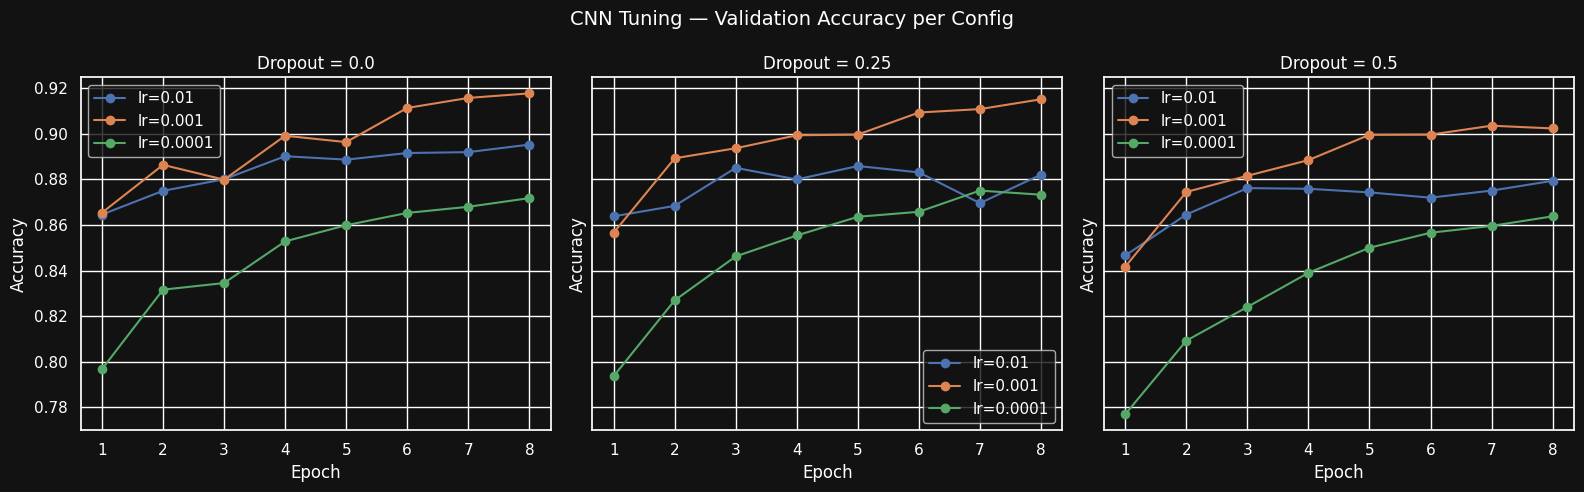

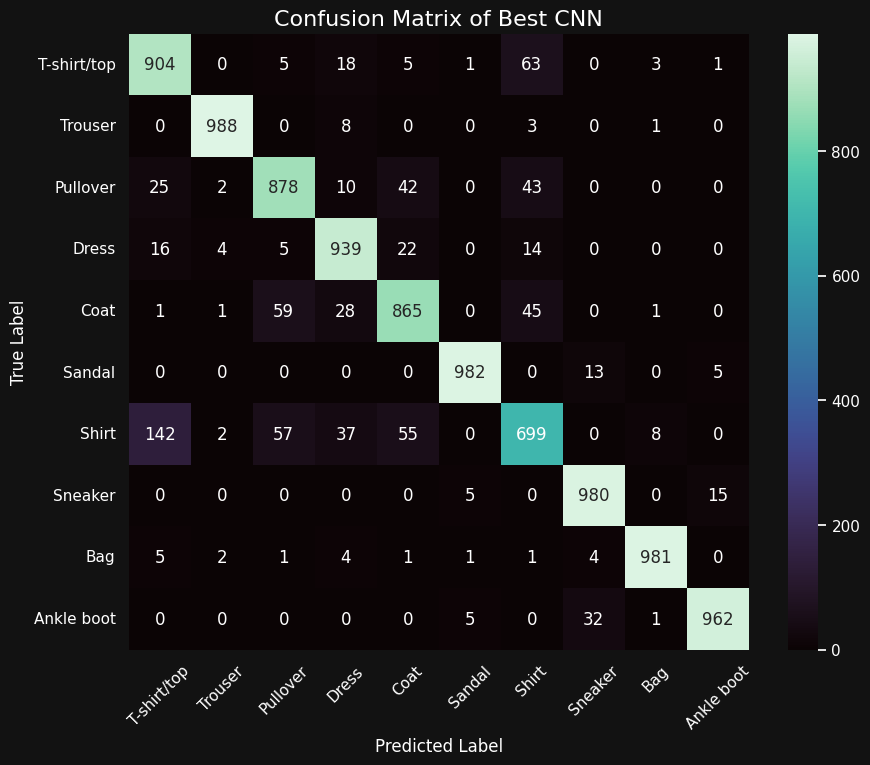


--- Classification Report ---
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.90      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.87      0.88      0.88      1000
       Dress       0.90      0.94      0.92      1000
        Coat       0.87      0.86      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.81      0.70      0.75      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.98      0.98      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

── Best KNN ──────────────────────────────────────
  Accuracy : 81.05%
  F1 Score : 81.27%
              precision    recall  f1-score   support

 T-shirt/top       0.66      0.80      0.72       200
     Trous

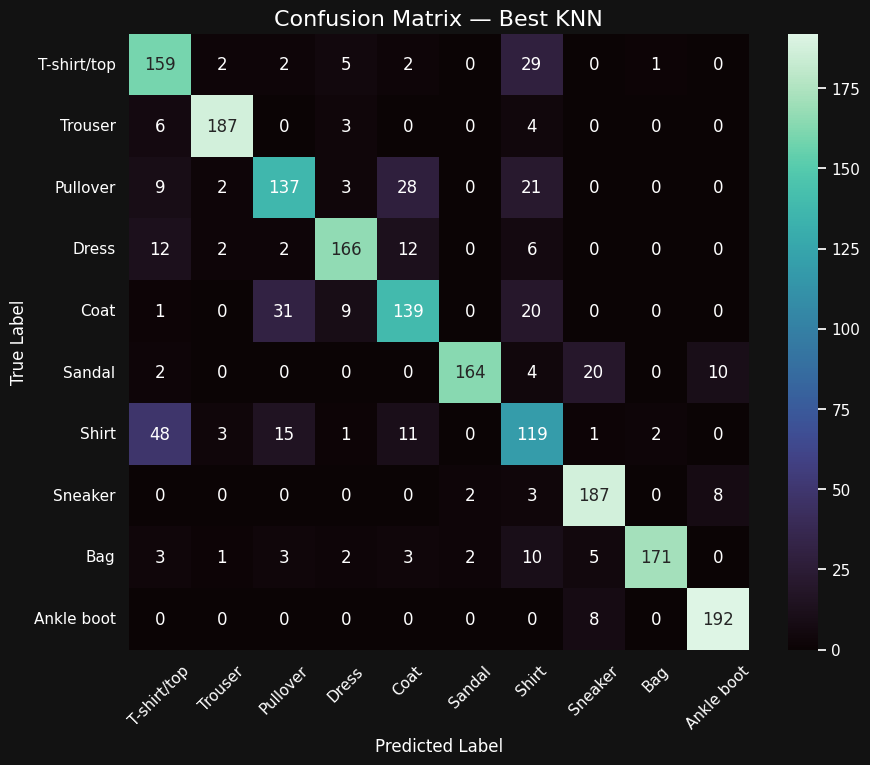

── Best SVM RBF ──────────────────────────────────────
  Accuracy : 86.80%
  F1 Score : 86.80%
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.82      0.82       200
     Trouser       0.99      0.95      0.97       200
    Pullover       0.73      0.72      0.73       200
       Dress       0.87      0.92      0.89       200
        Coat       0.78      0.78      0.78       200
      Sandal       0.95      0.97      0.96       200
       Shirt       0.66      0.66      0.66       200
     Sneaker       0.95      0.95      0.95       200
         Bag       0.96      0.96      0.96       200
  Ankle boot       0.96      0.95      0.96       200

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



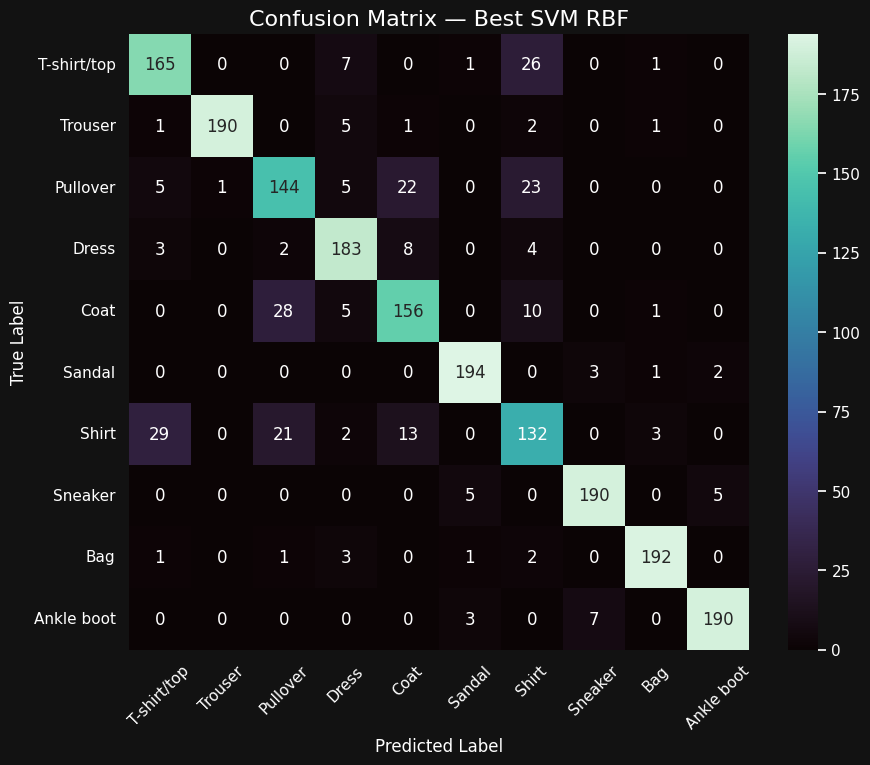

── Best SVM Polynomial ──────────────────────────────────────
  Accuracy : 85.85%
  F1 Score : 86.00%
              precision    recall  f1-score   support

 T-shirt/top       0.80      0.82      0.81       200
     Trouser       0.99      0.95      0.97       200
    Pullover       0.76      0.69      0.73       200
       Dress       0.88      0.89      0.88       200
        Coat       0.78      0.77      0.77       200
      Sandal       0.97      0.94      0.95       200
       Shirt       0.61      0.69      0.65       200
     Sneaker       0.91      0.95      0.93       200
         Bag       0.96      0.93      0.95       200
  Ankle boot       0.97      0.94      0.96       200

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



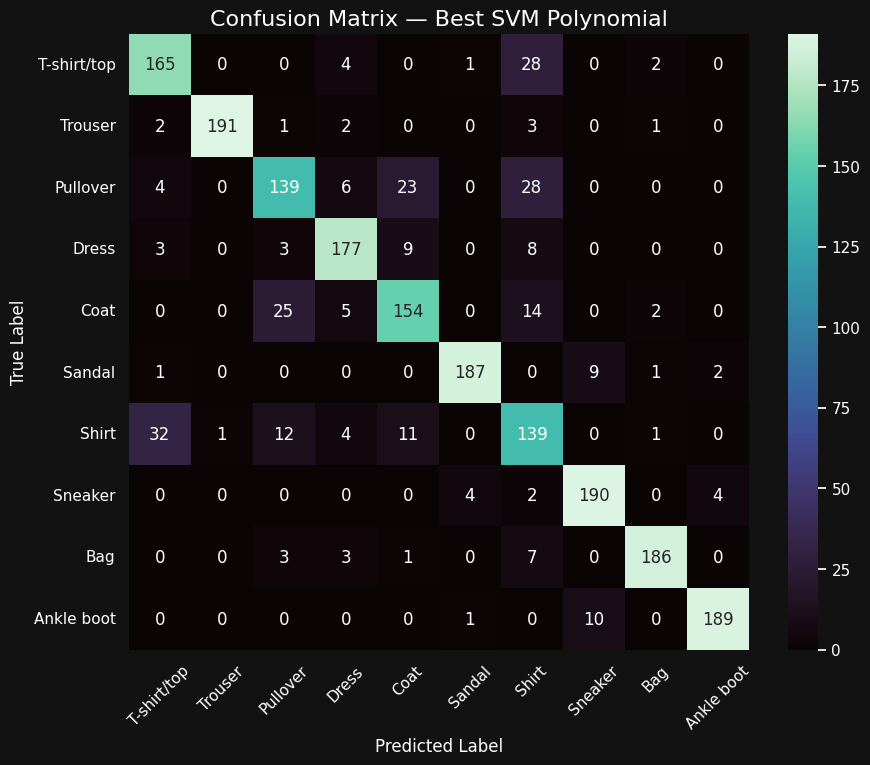

(0.8585, 0.8600106392262744)

In [ ]:
# ==========================================
# PRELIMINARY RESULTS (VISUALIZATIONS)
# ==========================================

# Summary table of CNN tuning
print("\n--- CNN Hyperparameter Tuning Summary ---")
df_results = pd.DataFrame([{
    'Learning Rate': r['LR'],
    'Dropout Rate':  r['Dropout'],
    'Validation Accuracy': round(r['Final_Accuracy'] * 100, 2)
} for r in cnn_results]).sort_values('Validation Accuracy', ascending=False)
display(df_results)

# Training curves — grouped by dropout rate
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('CNN Tuning — Validation Accuracy per Config', fontsize=14, color='white')
for ax, dr in zip(axes, [0.0, 0.25, 0.5]):
    configs = [r for r in cnn_results if r['Dropout'] == dr]
    for res in configs:
        ax.plot(res['History']['val_acc'], marker='o', label=f"lr={res['LR']}")
    ax.set_title(f'Dropout = {dr}', color='white')
    ax.set_xlabel('Epoch', color='white')
    ax.set_ylabel('Accuracy', color='white')
    ax.set_xticks(range(8))
    ax.set_xticklabels(range(1, 9))
    ax.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
def evaluate_best_model(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix of Best CNN', color='white', fontsize=16)
    plt.xlabel('Predicted Label', color='white')
    plt.ylabel('True Label', color='white')
    plt.xticks(rotation=45)
    plt.show()
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

evaluate_best_model(best_cnn_model)   # ← was best_model
evaluate_sklearn_model(best_knn_model,  X_test_sub, y_test_sub, classes, "Best KNN")
evaluate_sklearn_model(best_rbf_model,  X_test_sub, y_test_sub, classes, "Best SVM RBF")
evaluate_sklearn_model(best_poly_model, X_test_sub, y_test_sub, classes, "Best SVM Polynomial")

## 5. Visual Inference on Unseen Test Data

The best CNN model is used to predict on a random batch of 15 test images.
Predictions are color-coded: **green** indicates a correct prediction,
**red** indicates an incorrect one. This provides a qualitative view of
where the model succeeds and where it struggles.

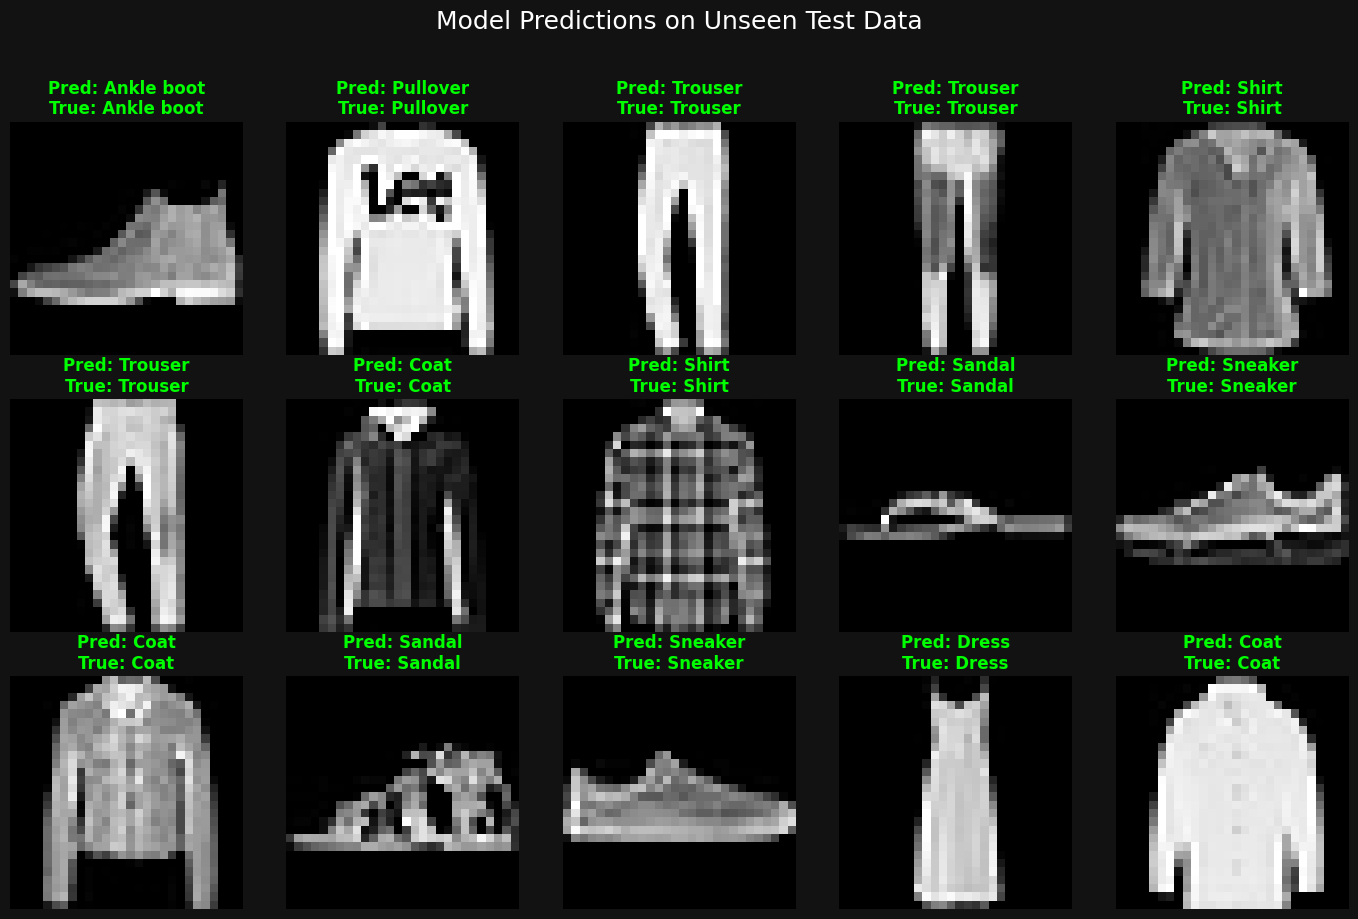


--- Batch Test Results ---
Correct Predictions: 60 / 64
Batch Accuracy: 93.75%


In [ ]:
# ==========================================
# FINAL TESTING & VISUAL INFERENCE
# ==========================================

def test_and_visualize(model, test_loader, num_images=15):
    # Grab a single batch of unseen test images
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images_device, labels_device = images.to(device), labels.to(device)

    # Set model to evaluation mode and get predictions
    model.eval()
    with torch.no_grad():
        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

    # Move data back to CPU for plotting
    images = images.cpu()
    predicted = predicted.cpu()
    labels = labels.cpu()

    # Set up the visualization
    fig, axes = plt.subplots(3, 5, figsize=(14, 9))
    fig.suptitle('Model Predictions on Unseen Test Data', fontsize=18, color='white', y=1.02)

    for i, ax in enumerate(axes.flat):
        if i >= num_images:
            break

        img = images[i].numpy().squeeze()
        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]

        # Color coding: Neon Green for Correct, Bright Red for Incorrect
        text_color = '#00FF00' if true_label == pred_label else '#FF3333'

        ax.imshow(img, cmap='gray')
        ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=text_color, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # Calculate and print the accuracy for this specific sample batch
    correct = (predicted == labels).sum().item()
    total = len(labels)
    print(f"\n--- Batch Test Results ---")
    print(f"Correct Predictions: {correct} / {total}")
    print(f"Batch Accuracy: {(correct/total)*100:.2f}%")

# Run the test using your best_model from the previous cell
test_and_visualize(best_cnn_model, val_loader)

## 6. Summary — All Methods Comparison

The table below consolidates the final accuracy and weighted F1-score of
all models (baseline and tuned) for direct comparison.

In [ ]:
# ==========================================
#  SUMMARY — ALL METHODS COMPARISON
# ==========================================
best_cnn_acc     = max(r['Final_Accuracy'] for r in cnn_results)
best_cnn_cfg     = max(cnn_results, key=lambda r: r['Final_Accuracy'])
best_cnn_lr      = best_cnn_cfg['LR']
best_cnn_dropout = best_cnn_cfg['Dropout']

summary = pd.DataFrame({
    "Method": [
        "CNN (best config)",
        "KNN Baseline",
        "KNN (GridSearchCV)",
        "SVM RBF Baseline",
        "SVM Poly Baseline",
        "SVM RBF (GridSearchCV)",
        "SVM Poly (GridSearchCV)",
    ],
    "Key Params": [
        f"LR={best_cnn_lr}, Dropout={best_cnn_dropout}",
        "k=5, euclidean",
        str(grid_knn.best_params_),
        "C=5, gamma=0.005",
        "C=1, degree=3",
        str(grid_rbf.best_params_),
        str(grid_poly.best_params_),
    ],
    "Accuracy (%)": [
        round(best_cnn_acc*100, 2),
        round(knn_base_acc*100, 2),
        round(best_knn_acc*100, 2),
        round(rbf_base_acc*100, 2),
        round(poly_base_acc*100, 2),
        round(best_rbf_acc*100, 2),
        round(best_poly_acc*100, 2),
    ],
    "F1 Score (%)": [
        round(best_cnn_acc*100, 2),
        round(knn_base_f1*100,  2),
        round(best_knn_f1*100,  2),
        round(rbf_base_f1*100,  2),
        round(poly_base_f1*100, 2),
        round(best_rbf_f1*100,  2),
        round(best_poly_f1*100, 2),
    ]
})

print("── All Methods Comparison ───────────────────────────────")
display(summary)
best_idx = summary["Accuracy (%)"].idxmax()
print(f"\nBest overall: {summary.loc[best_idx, 'Method']} — {summary.loc[best_idx, 'Accuracy (%)']}%")

── All Methods Comparison ───────────────────────────────


,Method,Key Params,Accuracy (%),F1 Score (%)
0,CNN (best config),"LR=0.001, Dropout=0.0",91.78,91.78
1,KNN Baseline,"k=5, euclidean",80.85,81.13
2,KNN (GridSearchCV),"{'kneighborsclassifier__metric': 'manhattan', ...",81.05,81.27
3,SVM RBF Baseline,"C=5, gamma=0.005",86.80,86.80
4,SVM Poly Baseline,"C=1, degree=3",79.95,81.45
5,SVM RBF (GridSearchCV),"{'svc__C': 5, 'svc__gamma': 0.005}",86.80,86.80
6,SVM Poly (GridSearchCV),"{'svc__C': 1, 'svc__degree': 2, 'svc__gamma': ...",85.85,86.00



Best overall: CNN (best config) — 91.78%


## 7. Save Best Models

The best-performing model from each method is saved to disk:
- `best_cnn.pth` — PyTorch state dict for the best CNN
- `best_knn.pkl` — scikit-learn pipeline (PCA + KNN)
- `best_svm.pkl` — scikit-learn pipeline (PCA + best SVM kernel)

These files are loaded in the Demo section below without retraining.

In [ ]:
# ==========================================
#  SAVE BEST MODELS
# ==========================================
import joblib
import os

save_dir = './saved_models'
os.makedirs(save_dir, exist_ok=True)

# Save best CNN
torch.save(best_cnn_model.state_dict(), f'{save_dir}/best_cnn.pth')
print(f"✔ CNN saved  → {save_dir}/best_cnn.pth")

# Save best KNN (sklearn Pipeline: PCA + KNN)
joblib.dump(best_knn_model, f'{save_dir}/best_knn.pkl')
print(f"✔ KNN saved  → {save_dir}/best_knn.pkl")

# Save best SVM — keep the higher-accuracy one
best_svm_name  = 'SVM-RBF'  if best_rbf_acc >= best_poly_acc else 'SVM-Poly'
best_svm_model = best_rbf_model if best_rbf_acc >= best_poly_acc else best_poly_model
joblib.dump(best_svm_model, f'{save_dir}/best_svm.pkl')
print(f"✔ SVM saved  → {save_dir}/best_svm.pkl  ({best_svm_name})")


✔ CNN saved  → ./saved_models/best_cnn.pth
✔ KNN saved  → ./saved_models/best_knn.pkl
✔ SVM saved  → ./saved_models/best_svm.pkl  (SVM-RBF)


## 8. Demo — Inference on 5 Fixed Test Examples

The three saved models are loaded from disk and used to classify 5 fixed
test examples. Each example comes from a different class to ensure variety.
Predictions from all three models are shown side by side against the true
label, with ✔ for correct and ✘ for incorrect predictions.

Selected test examples:
  Sample 1: index=6618  true_label='Dress'
  Sample 2: index=3278  true_label='Pullover'
  Sample 3: index=9821  true_label='Bag'
  Sample 4: index=2929  true_label='Trouser'
  Sample 5: index=2183  true_label='Sandal'

Sample   True Label     CNN Pred         KNN Pred         SVM Pred        
------------------------------------------------------------------------
  1      Dress          Dress       ✔    Dress       ✔    Dress       ✔   
  2      Pullover       Pullover    ✔    Pullover    ✔    Pullover    ✔   
  3      Bag            Bag         ✔    Bag         ✔    Bag         ✔   
  4      Trouser        Trouser     ✔    Trouser     ✔    Trouser     ✔   
  5      Sandal         Sandal      ✔    Sandal      ✔    Sandal      ✔   

Demo accuracy (5 samples) — CNN: 5/5  KNN: 5/5  SVM: 5/5


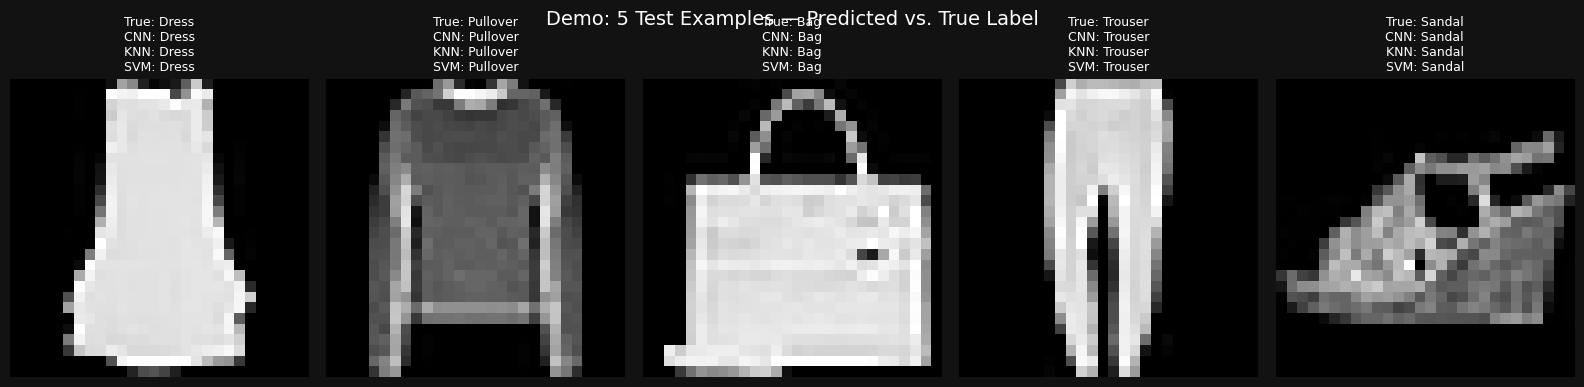

In [ ]:
# ==========================================
#  DEMO — 5 FIXED TEST EXAMPLES
# Load saved models and compare predictions vs. ground truth
# ==========================================
import random
import joblib
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ── Reload data (safe to re-run independently) ─────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])
test_ds   = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                               download=True, transform=transform)
classes   = test_ds.classes   # 10 Fashion-MNIST class names

# ── Pick 5 FIXED diverse test examples (one per every 2 classes) ───────────
random.seed(99)
selected_indices = []
seen_classes = set()
for idx in random.sample(range(len(test_ds)), len(test_ds)):
    label = test_ds.targets[idx].item()
    if label not in seen_classes:
        selected_indices.append(idx)
        seen_classes.add(label)
    if len(selected_indices) == 5:
        break

test_images_tensor = torch.stack([test_ds[i][0] for i in selected_indices])   # (5,1,28,28)
test_labels        = [test_ds[i][1] for i in selected_indices]
true_label_names   = [classes[l] for l in test_labels]

print("Selected test examples:")
for i, (idx, lbl) in enumerate(zip(selected_indices, true_label_names)):
    print(f"  Sample {i+1}: index={idx}  true_label='{lbl}'")

# ── Load saved CNN ─────────────────────────────────────────────────────────
cnn_loaded = FashionCNN(dropout_rate=0.25).to(device)  # use best dropout from grid
cnn_loaded.load_state_dict(torch.load(f'{save_dir}/best_cnn.pth',
                                      map_location=device))
cnn_loaded.eval()

with torch.no_grad():
    cnn_outputs  = cnn_loaded(test_images_tensor.to(device))
    cnn_preds    = torch.argmax(cnn_outputs, dim=1).cpu().tolist()
cnn_pred_names   = [classes[p] for p in cnn_preds]

# ── Load saved KNN ─────────────────────────────────────────────────────────
knn_loaded       = joblib.load(f'{save_dir}/best_knn.pkl')
X_demo_flat      = test_images_tensor.numpy().reshape(5, -1)  # (5, 784)
knn_preds        = knn_loaded.predict(X_demo_flat).tolist()
knn_pred_names   = [classes[p] for p in knn_preds]

# ── Load saved SVM ─────────────────────────────────────────────────────────
svm_loaded       = joblib.load(f'{save_dir}/best_svm.pkl')
svm_preds        = svm_loaded.predict(X_demo_flat).tolist()
svm_pred_names   = [classes[p] for p in svm_preds]

# ── Print structured comparison table ─────────────────────────────────────
print("\n" + "="*72)
print(f"{'Sample':<8} {'True Label':<14} {'CNN Pred':<16} {'KNN Pred':<16} {'SVM Pred':<16}")
print("-"*72)
for i in range(5):
    def mark(pred, true): return "✔" if pred == true else "✘"
    print(f"  {i+1:<6} {true_label_names[i]:<14} "
          f"{cnn_pred_names[i]:<12}{mark(cnn_pred_names[i], true_label_names[i]):<4} "
          f"{knn_pred_names[i]:<12}{mark(knn_pred_names[i], true_label_names[i]):<4} "
          f"{svm_pred_names[i]:<12}{mark(svm_pred_names[i], true_label_names[i]):<4}")
print("="*72)

cnn_score = sum(c == t for c, t in zip(cnn_pred_names, true_label_names))
knn_score = sum(k == t for k, t in zip(knn_pred_names, true_label_names))
svm_score = sum(s == t for s, t in zip(svm_pred_names, true_label_names))
print(f"\nDemo accuracy (5 samples) — CNN: {cnn_score}/5  KNN: {knn_score}/5  SVM: {svm_score}/5")

# ── Visual output ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Demo: 5 Test Examples — Predicted vs. True Label',
             fontsize=14, color='white')

for i, ax in enumerate(axes):
    img = test_images_tensor[i].numpy().squeeze()
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    cnn_c = '#00FF00' if cnn_pred_names[i] == true_label_names[i] else '#FF3333'
    knn_c = '#00FF00' if knn_pred_names[i] == true_label_names[i] else '#FF3333'
    svm_c = '#00FF00' if svm_pred_names[i] == true_label_names[i] else '#FF3333'
    title = (f"True: {true_label_names[i]}\n"
             f"CNN: {cnn_pred_names[i]}\n"
             f"KNN: {knn_pred_names[i]}\n"
             f"SVM: {svm_pred_names[i]}")
    ax.set_title(title, fontsize=9, color='white', loc='center')

plt.tight_layout()
plt.show()
